## Modeling with **K-Nearest Neighbors**, **Red Wine Quality Prediction**
[Link to KNeighborsClassifier Documentation](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

### Introduction
##### This project explores the use of the **K-Nearest Neighbors (KNN)** algorithm to analyze and predict **wine quality** based on various **chemical properties**. 
##### The quality of wine is influenced by factors such as **acidity**, **sugar levels**, **pH**, **alcohol content**, and more, each contributing to the wine's overall **taste profile**. 
##### By using a **dataset** of wines with these attributes, I aim to build a **machine learning model** that can predict the quality of a wine based on its chemical properties.

##### I chose the knn algorithm because **KNN algorithm** is particularly well-suited for this type of **classification problem** due to its **simplicity** and **effectiveness** in handling **multiclass classification tasks**. 
##### KNN makes predictions by finding the "**nearest neighbors**" to a data point and using the most common **class** among these neighbors as the **predicted class**. In this project, I **optimize** the KNN model through **hyperparameter tuning** and **assess its performance** to understand how well it can classify wines into **quality categories**.


In [218]:
import pandas as pd
import seaborn as sns

###### importing the dataset and observing a sample


In [219]:
redwine_df = pd.read_csv('../winequality-red-clean.csv', sep=',')
redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
986,11.6,0.41,0.54,1.5,0.095,22.0,41.0,0.99735,3.02,0.76,9.9,7
1385,6.1,0.32,0.25,2.3,0.071,23.0,58.0,0.99633,3.42,0.97,10.6,5
607,8.0,0.45,0.23,2.2,0.094,16.0,29.0,0.99620,3.21,0.49,10.2,6
909,8.2,0.43,0.29,1.6,0.081,27.0,45.0,0.99603,3.25,0.54,10.3,5
413,10.3,0.50,0.42,2.0,0.069,21.0,51.0,0.99820,3.16,0.72,11.5,6


##### checking the data types of the columns

In [220]:
info_data = {
    "Column": redwine_df.columns,
    "Non-Null Count": redwine_df.notnull().sum(),
    "Dtype": redwine_df.dtypes
}

# Create a DataFrame with this information
info_df = pd.DataFrame(info_data)

# Display the DataFrame as a table
print("Red Wine DataFrame Info:")
info_df

Red Wine DataFrame Info:


,Column,Non-Null Count,Dtype
fixed acidity,fixed acidity,1458,float64
volatile acidity,volatile acidity,1458,float64
citric acid,citric acid,1458,float64
residual sugar,residual sugar,1458,float64
chlorides,chlorides,1458,float64
free sulfur dioxide,free sulfur dioxide,1458,float64
total sulfur dioxide,total sulfur dioxide,1458,float64
density,density,1458,float64
pH,pH,1458,float64
sulphates,sulphates,1458,float64


##### Simple Descriptive Analysis and checking the distribution of the data

In [221]:
redwine_df.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1458.000000,8.312209,1.647586,5.000000,7.100000,7.900000,9.200000,13.500000
volatile acidity,1458.000000,0.524155,0.169595,0.120000,0.390000,0.520000,0.635000,1.040000
citric acid,1458.000000,0.265281,0.191271,0.000000,0.090000,0.250000,0.420000,0.790000
residual sugar,1458.000000,2.388717,0.865307,1.200000,1.900000,2.200000,2.600000,6.700000
chlorides,1458.000000,0.081580,0.021298,0.038000,0.070000,0.079000,0.089000,0.226000
free sulfur dioxide,1458.000000,15.089849,9.317669,1.000000,7.000000,13.000000,21.000000,47.000000
total sulfur dioxide,1458.000000,43.662209,29.414125,6.000000,21.000000,36.000000,58.000000,145.000000
density,1458.000000,0.996718,0.001718,0.991500,0.995600,0.996700,0.997800,1.002200
pH,1458.000000,3.316276,0.141196,2.880000,3.220000,3.315000,3.400000,3.750000
sulphates,1458.000000,0.642414,0.129753,0.330000,0.550000,0.620000,0.720000,1.160000


In [222]:
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

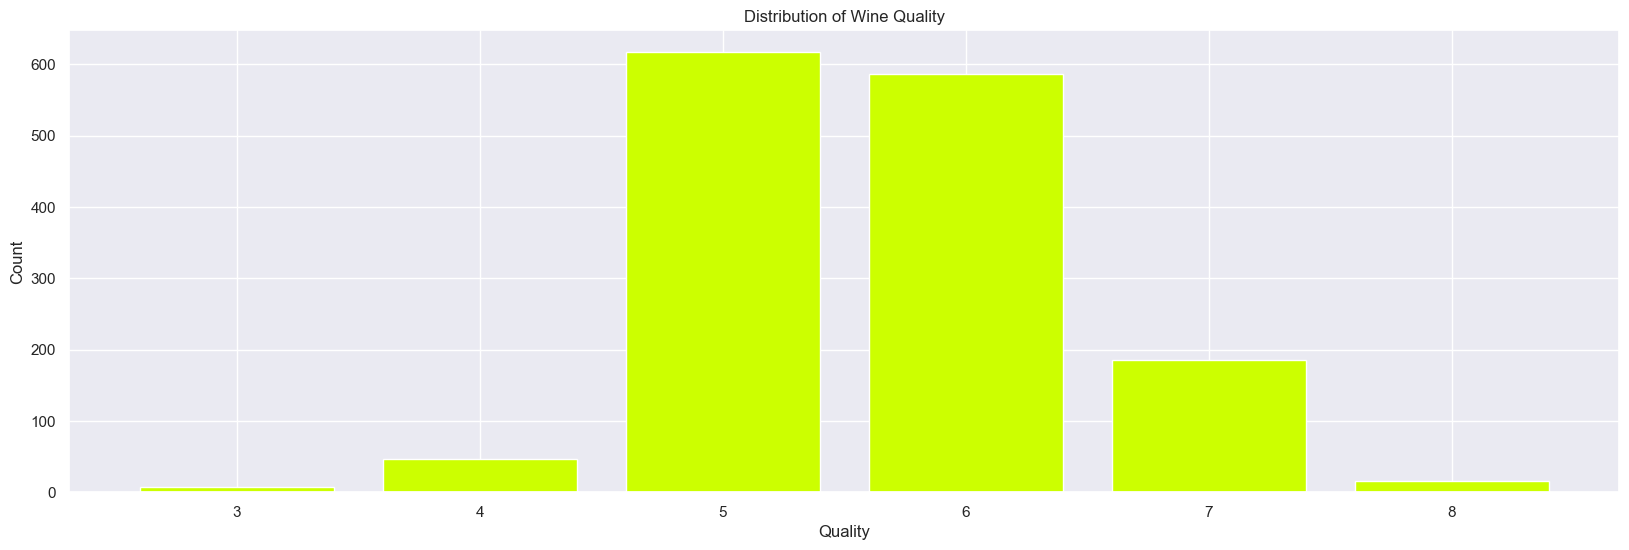

In [223]:
import pandas as pd
import matplotlib.pyplot as plt

quality_counts = redwine_df['quality'].value_counts().sort_index()

quality_df = pd.DataFrame({'quality': quality_counts.index, 'count': quality_counts.values})

plt.figure(figsize=(20, 6 ))
plt.bar(quality_df['quality'], quality_df['count'], color='#ccff00')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')
plt.xticks(quality_df['quality'])  # Ensure the x-axis labels match the quality values
plt.show()

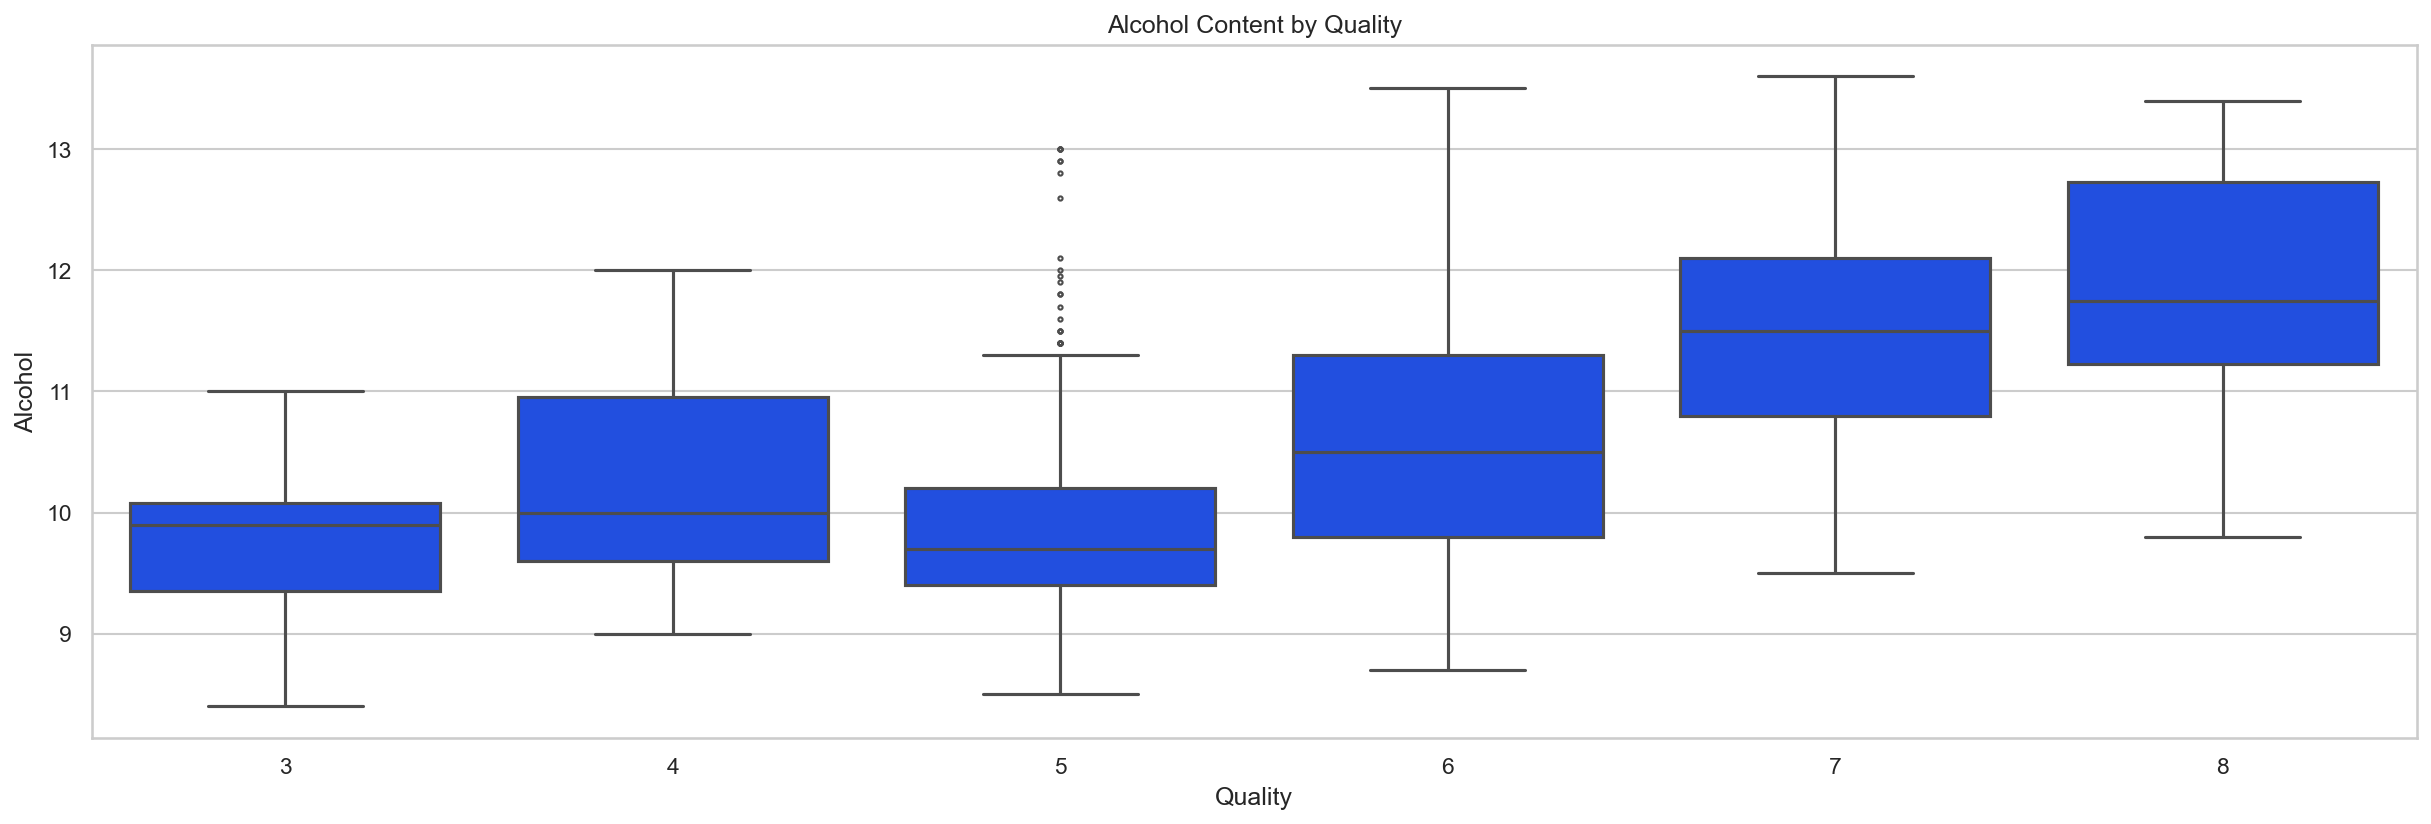

In [224]:
sns.set(style="whitegrid", palette="bright")
plt.figure(figsize=(20, 6), dpi=150)
sns.boxplot(x='quality', y='alcohol', data=redwine_df, linewidth=1.5, fliersize=2)
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.title('Alcohol Content by Quality')
plt.show()


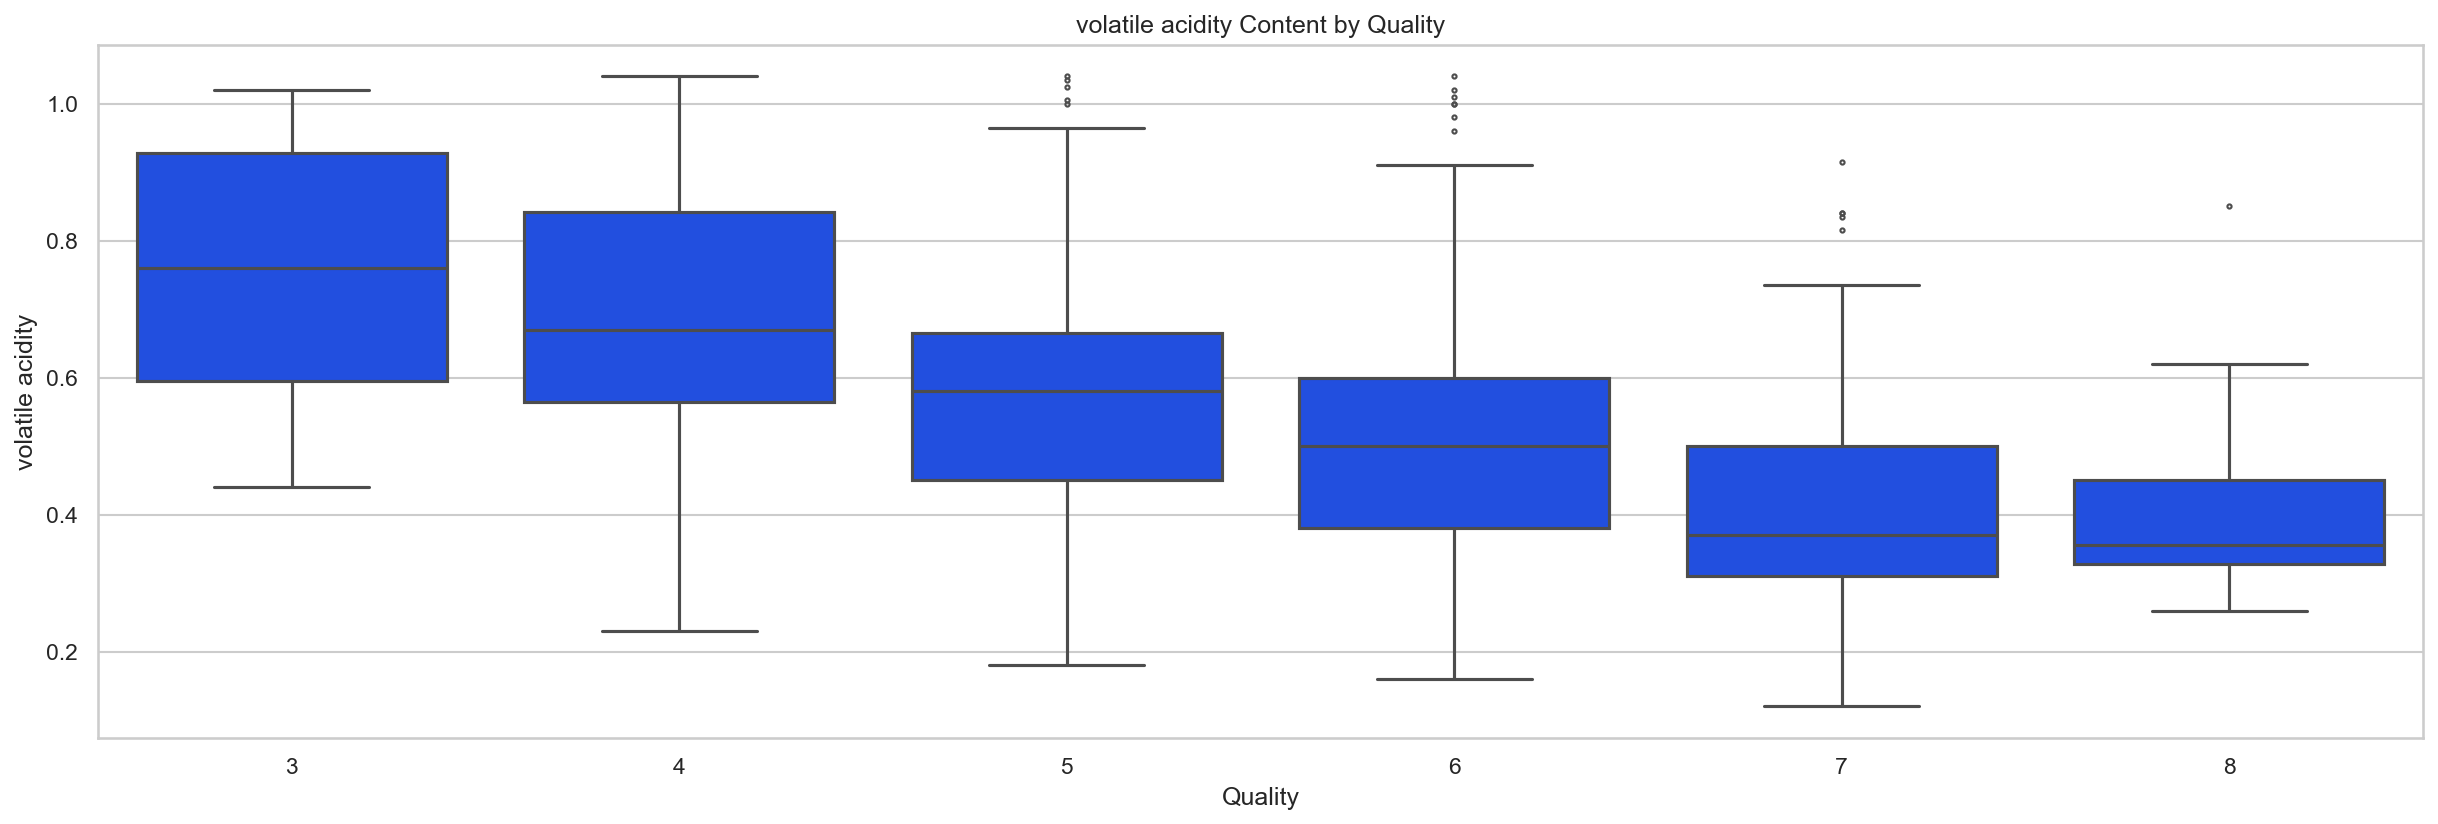

In [225]:
sns.set(style="whitegrid", palette="bright")
plt.figure(figsize=(20, 6), dpi=150)
sns.boxplot(x='quality', y='volatile acidity', data=redwine_df, linewidth=1.5, fliersize=2)
plt.xlabel('Quality')
plt.ylabel('volatile acidity')
plt.title('volatile acidity Content by Quality')
plt.show()


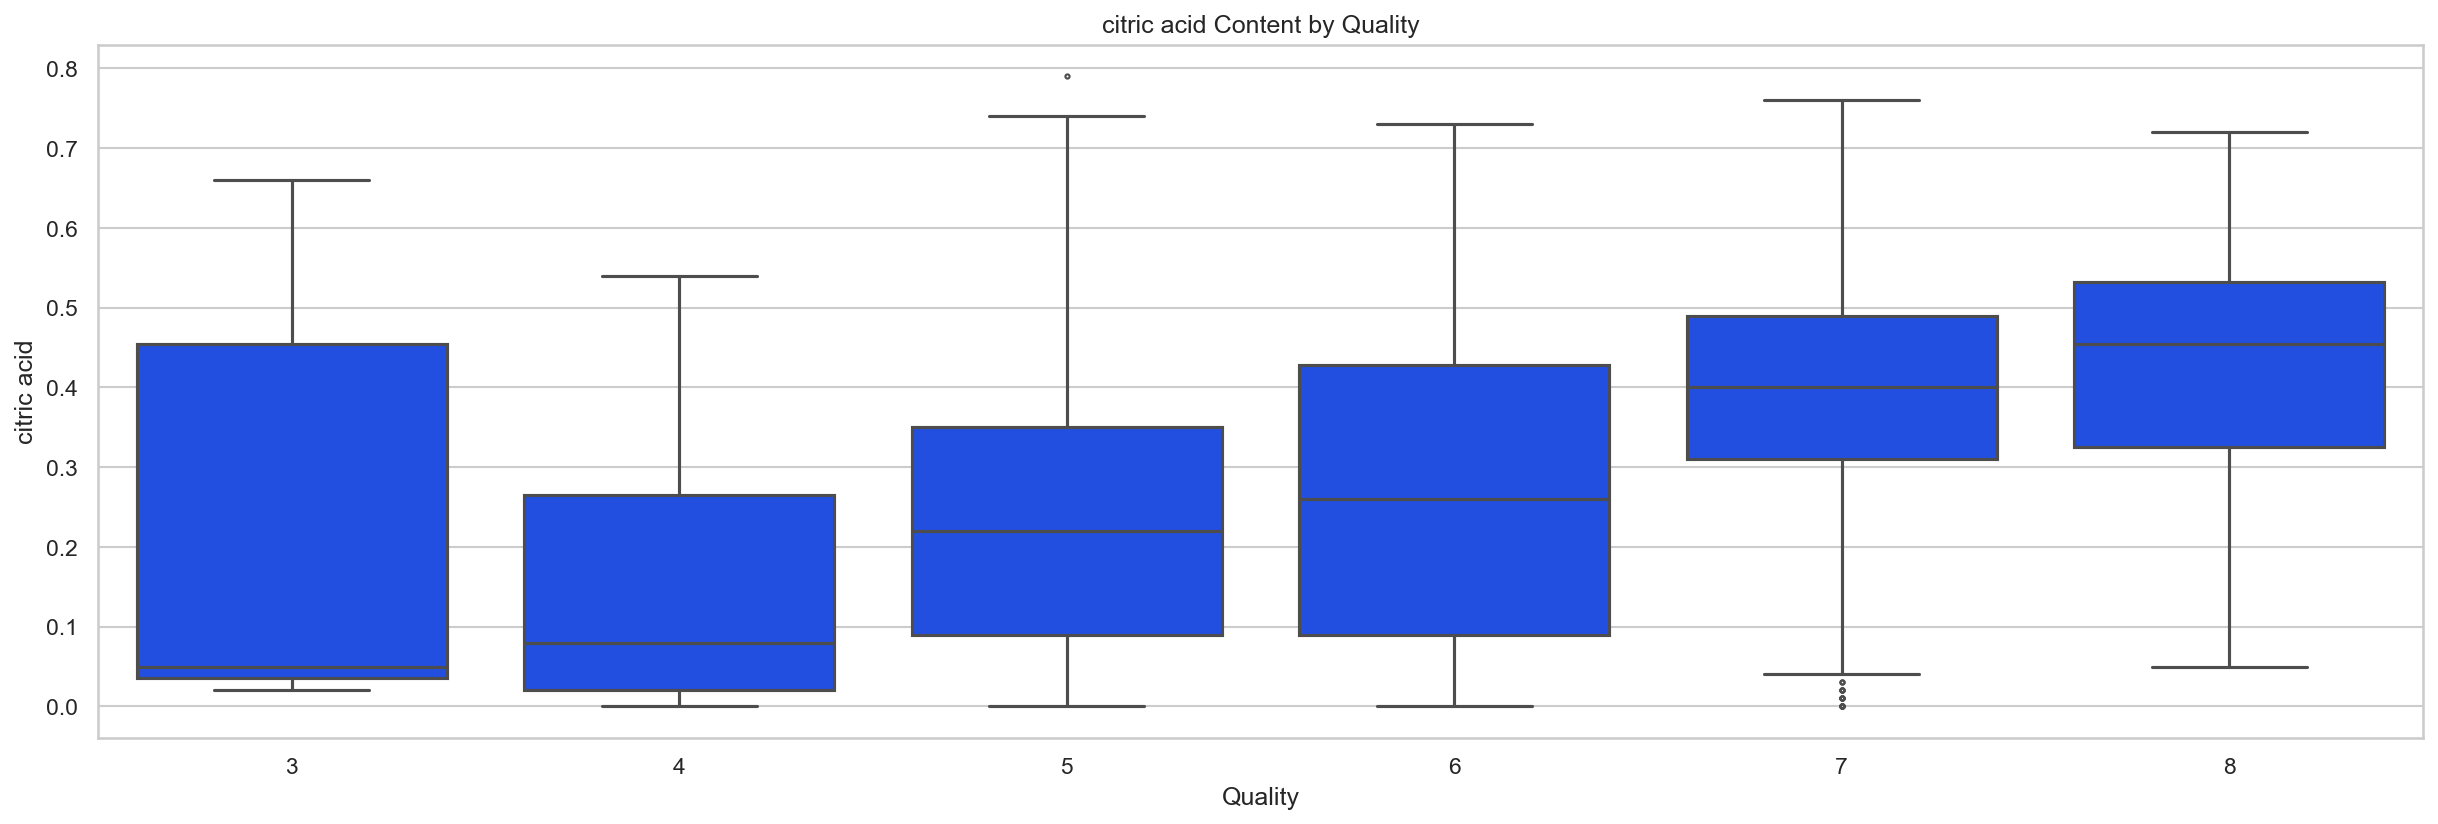

In [226]:
sns.set(style="whitegrid", palette="bright")
plt.figure(figsize=(20, 6), dpi=150)
sns.boxplot(x='quality', y='citric acid', data=redwine_df, linewidth=1.5, fliersize=2)
plt.xlabel('Quality')
plt.ylabel('citric acid')
plt.title('citric acid Content by Quality')
plt.show()


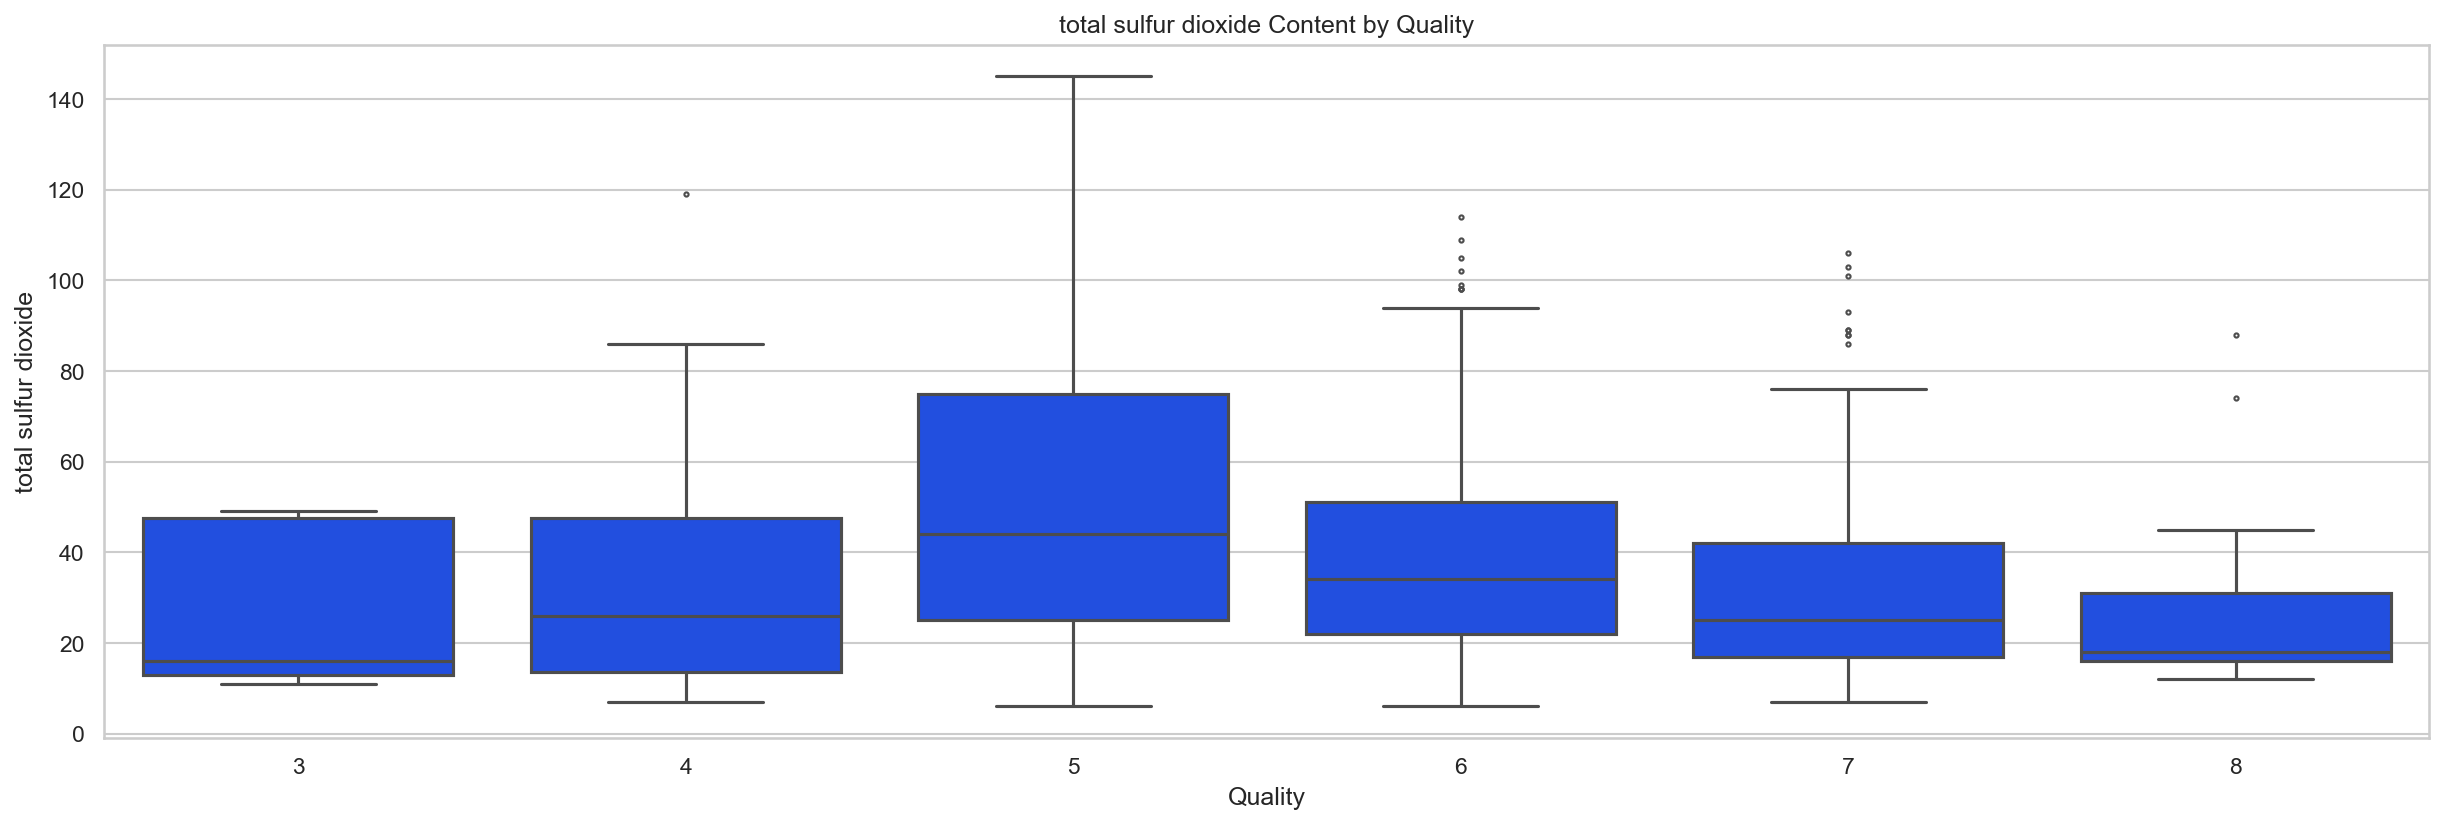

In [227]:
sns.set(style="whitegrid", palette="bright")
plt.figure(figsize=(20, 6), dpi=150)
sns.boxplot(x='quality', y='total sulfur dioxide', data=redwine_df, linewidth=1.5, fliersize=2)
plt.xlabel('Quality')
plt.ylabel('total sulfur dioxide')
plt.title('total sulfur dioxide Content by Quality')
plt.show()


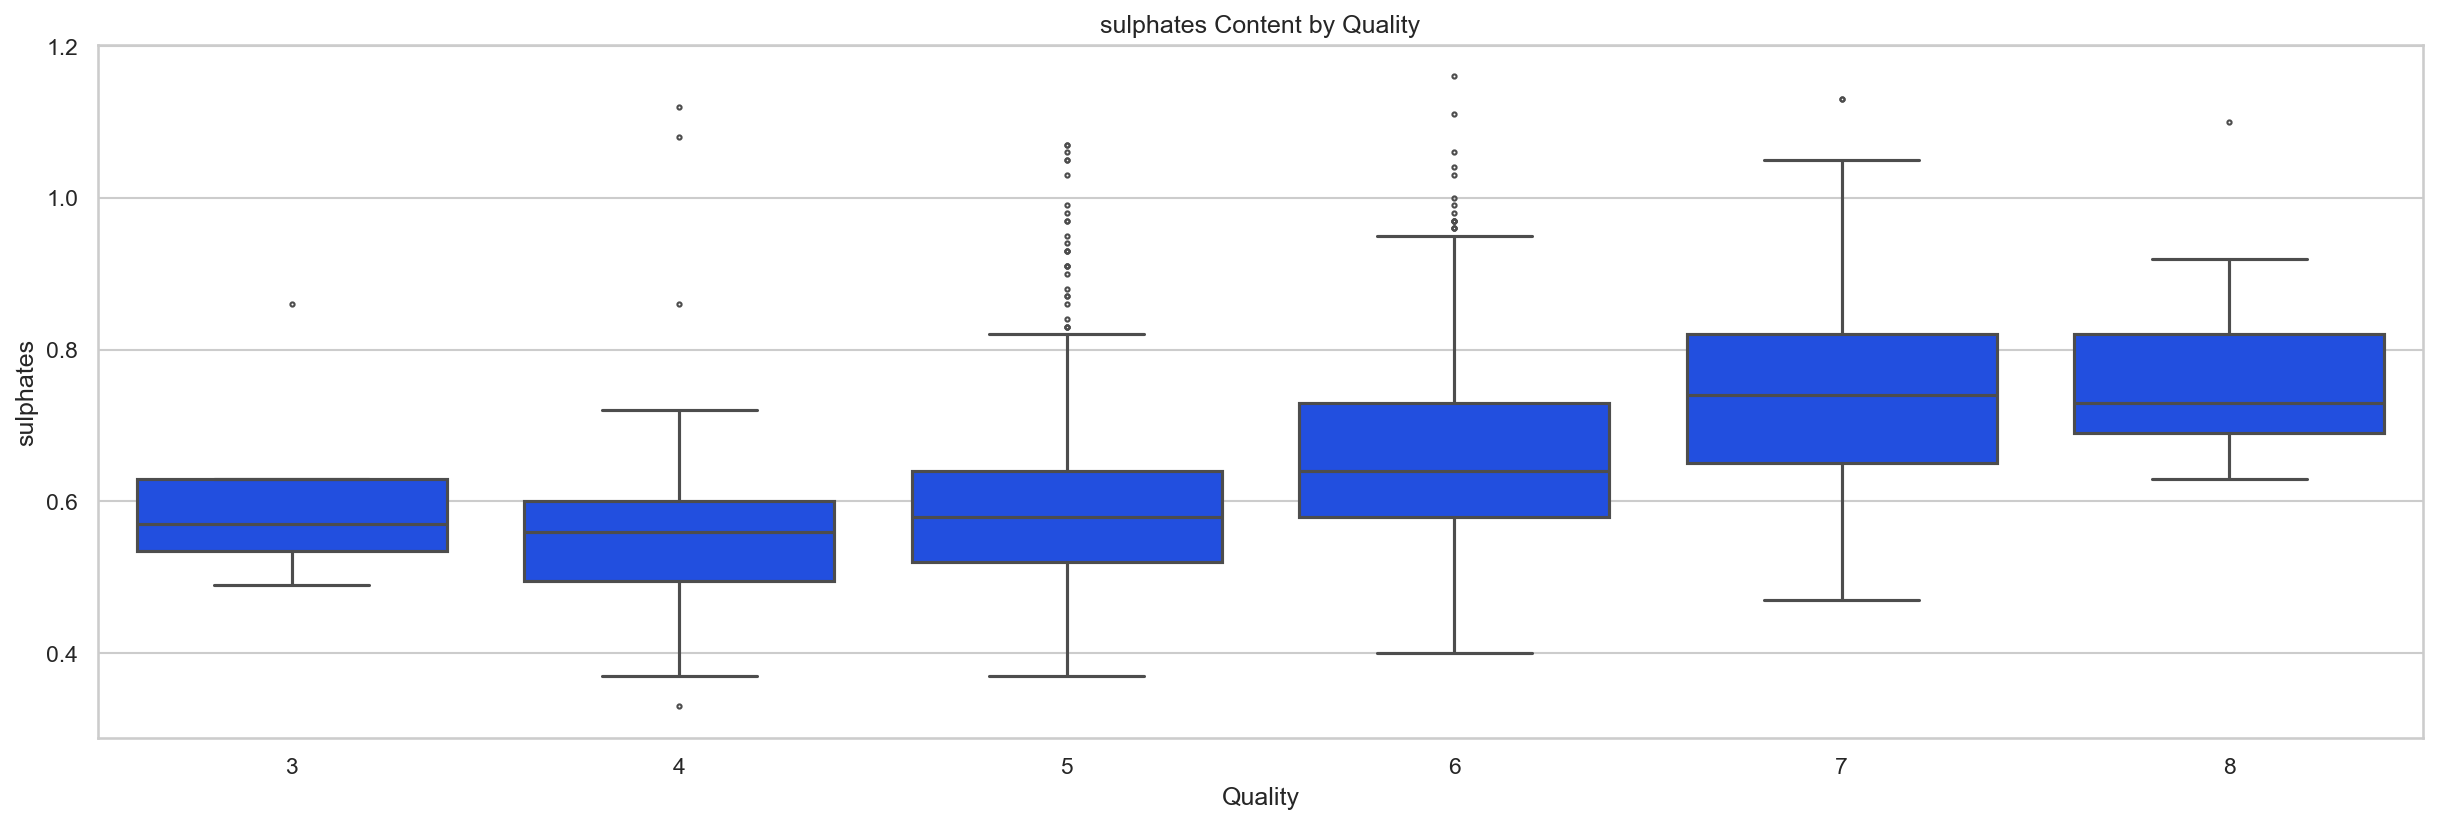

In [228]:
sns.set(style="whitegrid", palette="bright")
plt.figure(figsize=(20, 6), dpi=150)
sns.boxplot(x='quality', y='sulphates', data=redwine_df, linewidth=1.5, fliersize=2)
plt.xlabel('Quality')
plt.ylabel('sulphates')
plt.title('sulphates Content by Quality')
plt.show()


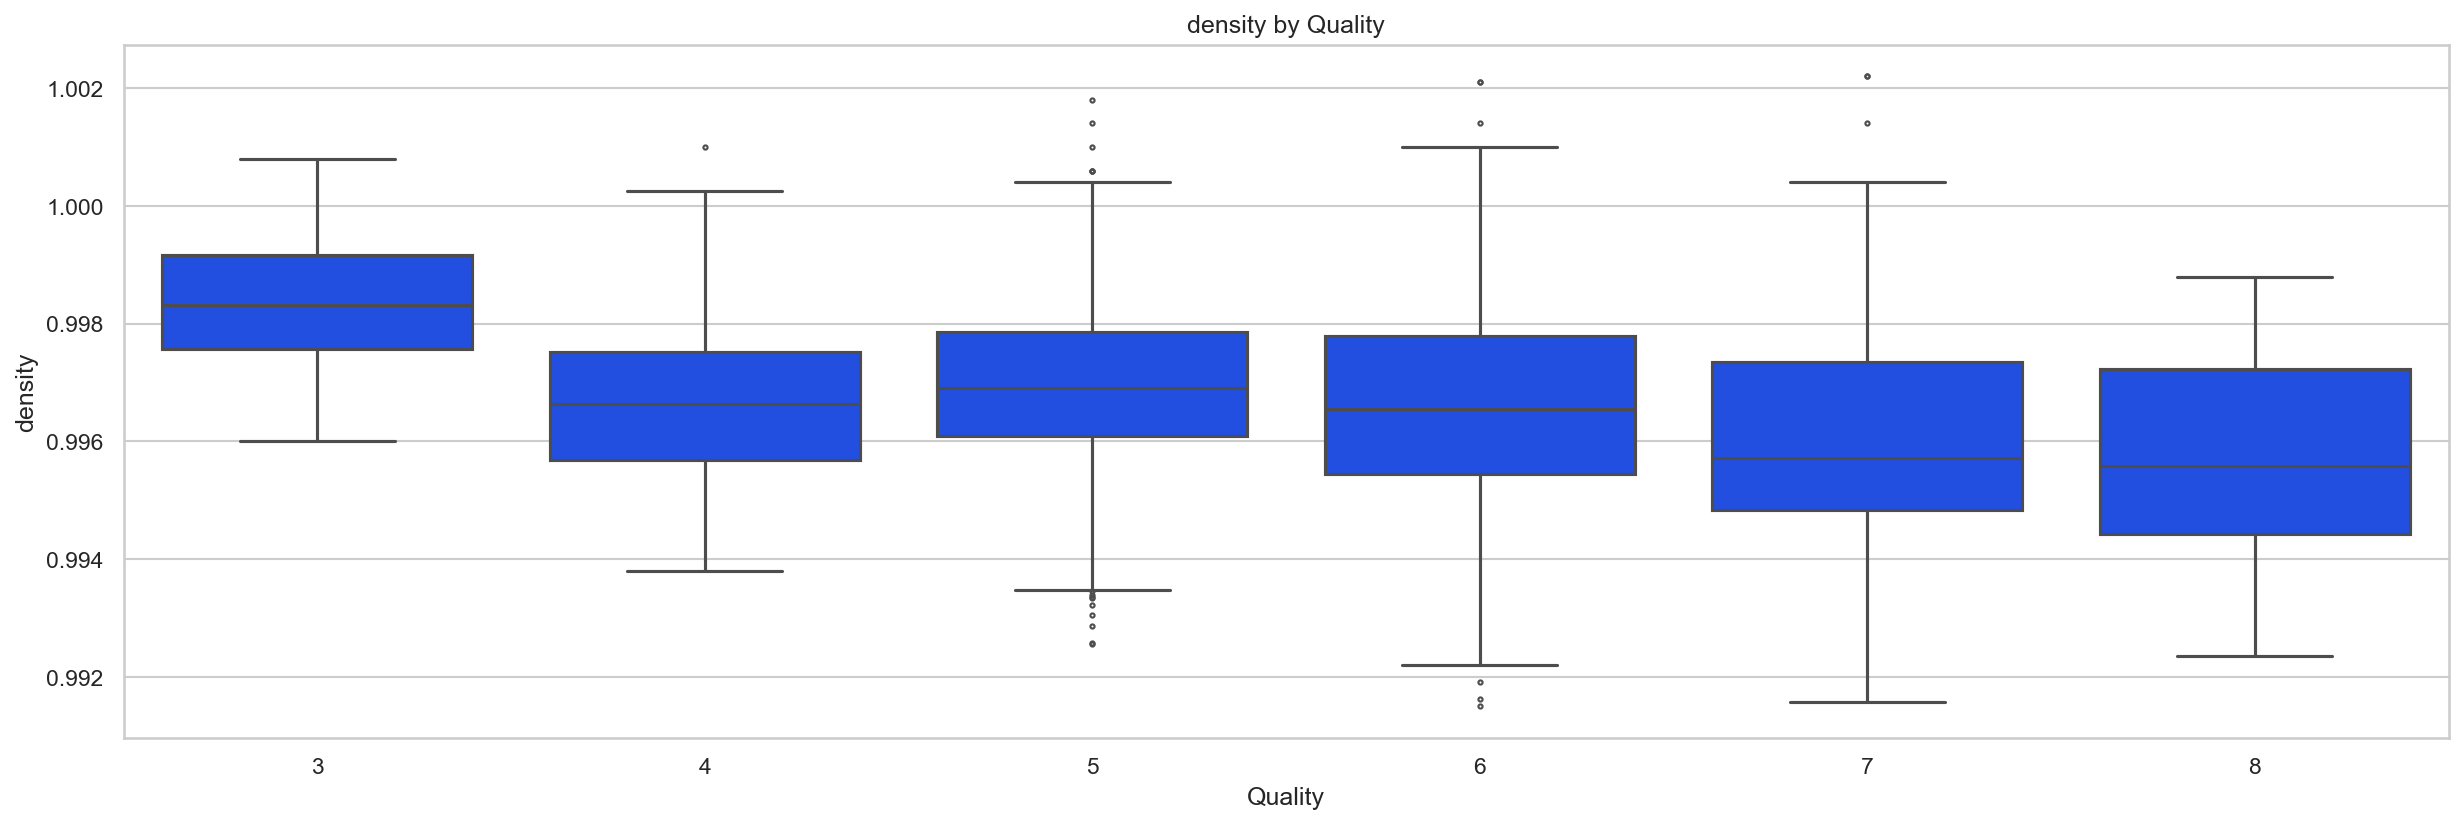

In [229]:
sns.set(style="whitegrid", palette="bright")
plt.figure(figsize=(20, 6), dpi=150)
sns.boxplot(x='quality', y='density', data=redwine_df, linewidth=1.5, fliersize=2)
plt.xlabel('Quality')
plt.ylabel('density')
plt.title('density by Quality')
plt.show()


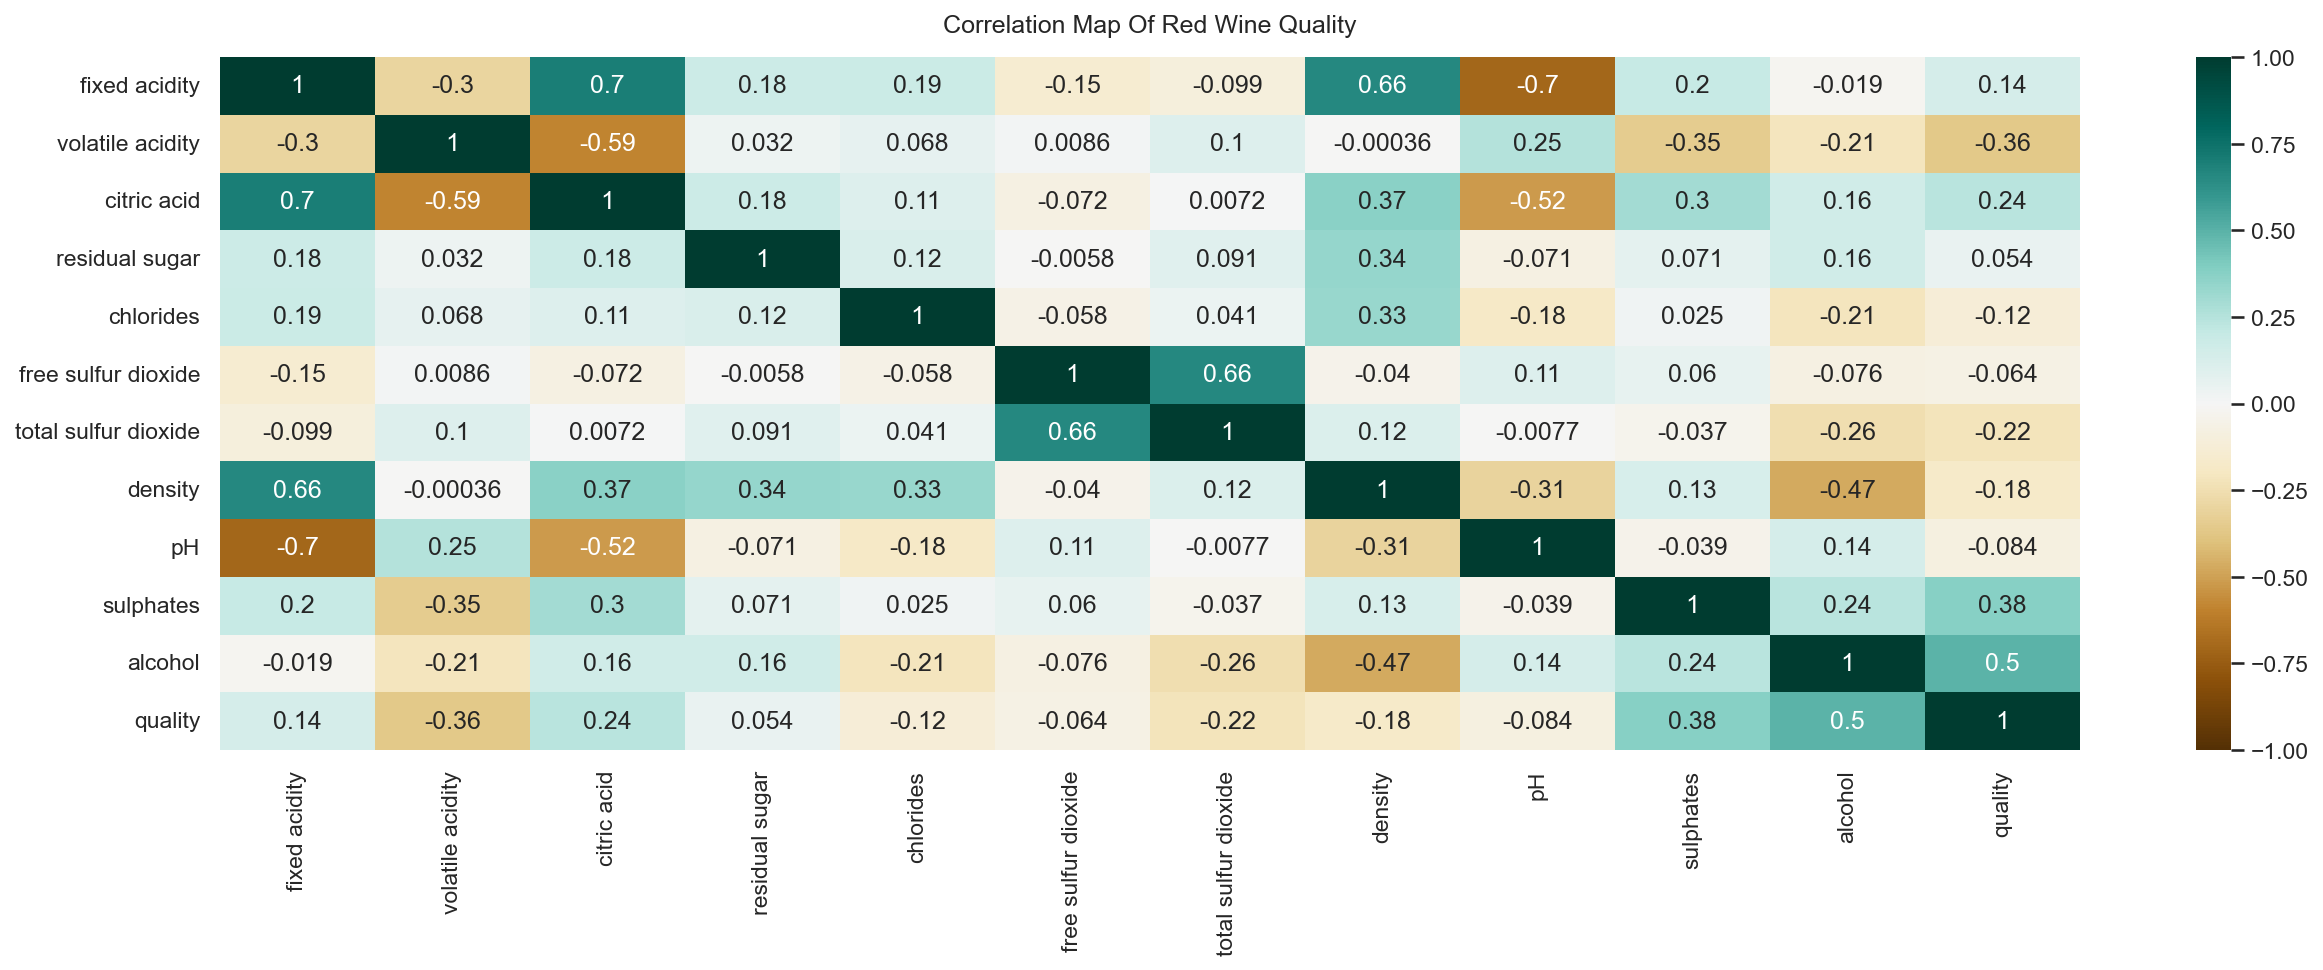

In [230]:
plt.figure(figsize=(20, 6), dpi=150)
sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
plt.title('Correlation Map Of Red Wine Quality', fontdict={'fontsize':12}, pad=12);

<Figure size 6000x3000 with 0 Axes>

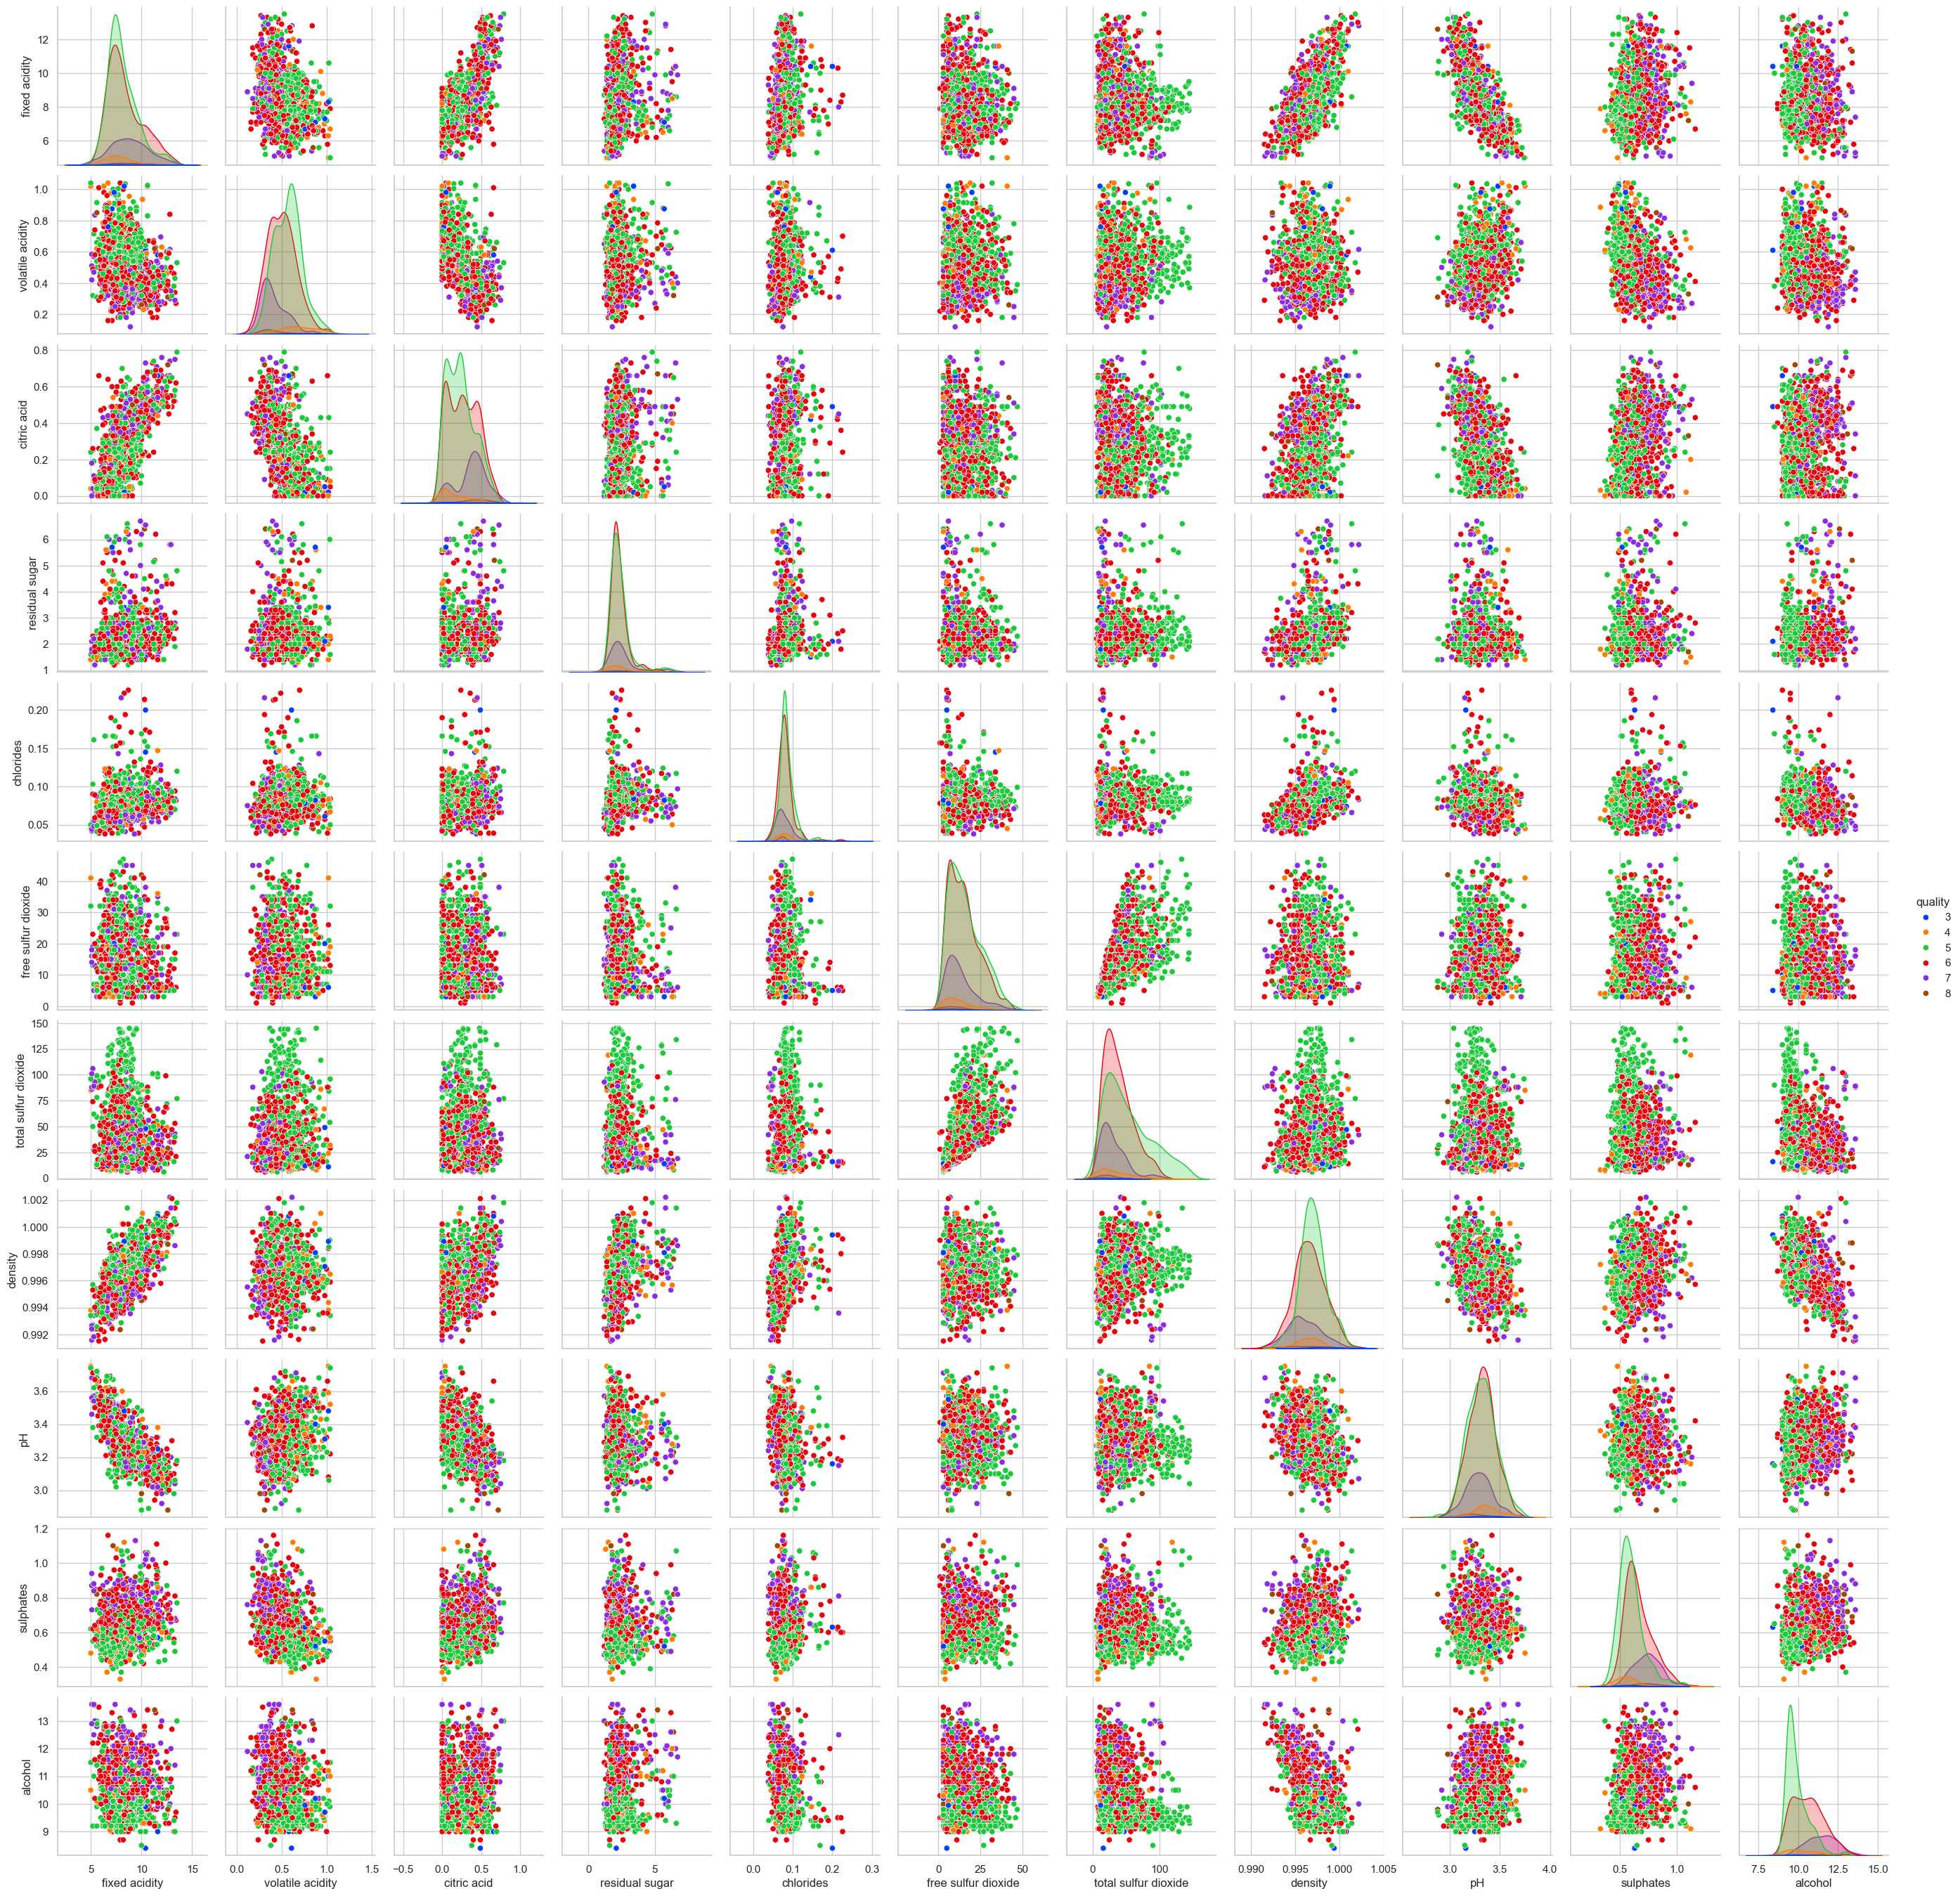

In [231]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

redwine_df['quality'] = redwine_df['quality'].astype('category')

# Select only numeric columns for the pairplot
numeric_cols = redwine_df.select_dtypes(include=['number']).columns
plot_df = redwine_df[numeric_cols].copy()
plot_df['quality'] = redwine_df['quality']

# Create the pair plot with a resolution of 300 DPI
plt.figure(figsize=(20, 10), dpi=300)
sns.pairplot(plot_df, hue='quality', plot_kws={'alpha': 1})

# Display the plot
plt.show()


### My observations from the heatmap, the box plots, and the pairplots are as follows:

- **Alcohol Content**: A positive relationship is evident between alcohol content and quality. Wines with higher alcohol content tend to have better quality ratings.

- **Volatile Acidity**: An inverse relationship is observed. As volatile acidity increases, the quality of the wine decreases, indicating that lower volatile acidity is preferable for higher-quality wines.

- **Citric Acid**: Higher levels of citric acid correlate with better quality, suggesting that citric acid contributes positively to wine quality.

- **Total Sulfur Dioxide**: There is an inverse relationship here; higher levels of total sulfur dioxide are associated with lower quality wines. This implies that lower sulfur dioxide levels are desirable for improved quality.

- **Sulphates**: A direct relationship is seen between sulphate levels and wine quality, with higher sulphates contributing positively to quality.

- **Density**: An inverse relationship is present between density and quality, where lower density is associated with higher-quality wines. Additionally, higher alcohol content tends to correlate with lower density, reinforcing this relationship.



##### splitting the data to test and train samples and use them to train the model.

In [232]:
X = redwine_df.drop(['quality'], axis = 1) # independent variables
y = redwine_df['quality'] # dependent variable

feature selecttion based on the cross validation in notebook "initial crosss validation"

In [233]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# selected features are selected based on the top features which have the highest correlation with the target variable.heatmap
selected_features = ['volatile acidity', 'citric acid', 'total sulfur dioxide', 'sulphates','alcohol']

In [234]:
X = redwine_df[selected_features]
y = redwine_df['quality']
# using standard scaler to scale the data and normalize it
standard_scaler = StandardScaler()
X = standard_scaler.fit_transform(X)
# splitting the data to test and train samples u    sing 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [235]:
X_train

array([[-1.08622536,  1.33217143,  0.31756836,  1.2920213 , -0.89876263],
       [-0.96825655,  0.23387791,  0.72567561, -0.17280534, -0.89876263],
       [ 0.27041599, -0.75981623, -0.26058357,  0.52105991,  0.86548633],
       ...,
       [-1.55810061,  0.54767606, -0.70269975,  0.44396377, -0.8007488 ],
       [-0.5553657 ,  0.70457513, -1.11080699, -0.78957445,  1.74761081],
       [ 1.2141665 , -1.38741253, -0.66869081, -1.40634356, -0.8007488 ]])

## *Find Best K-Score*

In [236]:
# this function will give a report about the overfitting and underfitting of the model
def analyze_overfitting_underfitting(k_values, overfitting_scores, overfitting_threshold=0.05, underfitting_threshold=-0.05):
    for idx, k in enumerate(k_values):

        overfitting_score = overfitting_scores[idx]

        if overfitting_score > overfitting_threshold:  print(f"At K={k}, the model has overfitting (Overfitting Score: {overfitting_score:.4f}).")

        elif overfitting_score < underfitting_threshold:  print(f"At K={k}, the model has underfitting (Overfitting Score: {overfitting_score:.4f}).")

        else: print(f"At K={k}, no significant overfitting or underfitting detected (Overfitting Score: {overfitting_score:.4f}).")


At K=3, the model has overfitting (Overfitting Score: 0.2300).
At K=4, the model has overfitting (Overfitting Score: 0.1365).
At K=5, the model has overfitting (Overfitting Score: 0.1125).
At K=6, the model has overfitting (Overfitting Score: 0.0894).
At K=7, the model has overfitting (Overfitting Score: 0.0696).
At K=8, the model has overfitting (Overfitting Score: 0.0594).
At K=9, the model has overfitting (Overfitting Score: 0.0533).
At K=10, the model has overfitting (Overfitting Score: 0.0645).
At K=11, no significant overfitting or underfitting detected (Overfitting Score: 0.0250).
At K=12, no significant overfitting or underfitting detected (Overfitting Score: 0.0447).
At K=13, the model has overfitting (Overfitting Score: 0.0559).
At K=14, no significant overfitting or underfitting detected (Overfitting Score: 0.0473).
At K=15, no significant overfitting or underfitting detected (Overfitting Score: 0.0482).
At K=16, no significant overfitting or underfitting detected (Overfitti

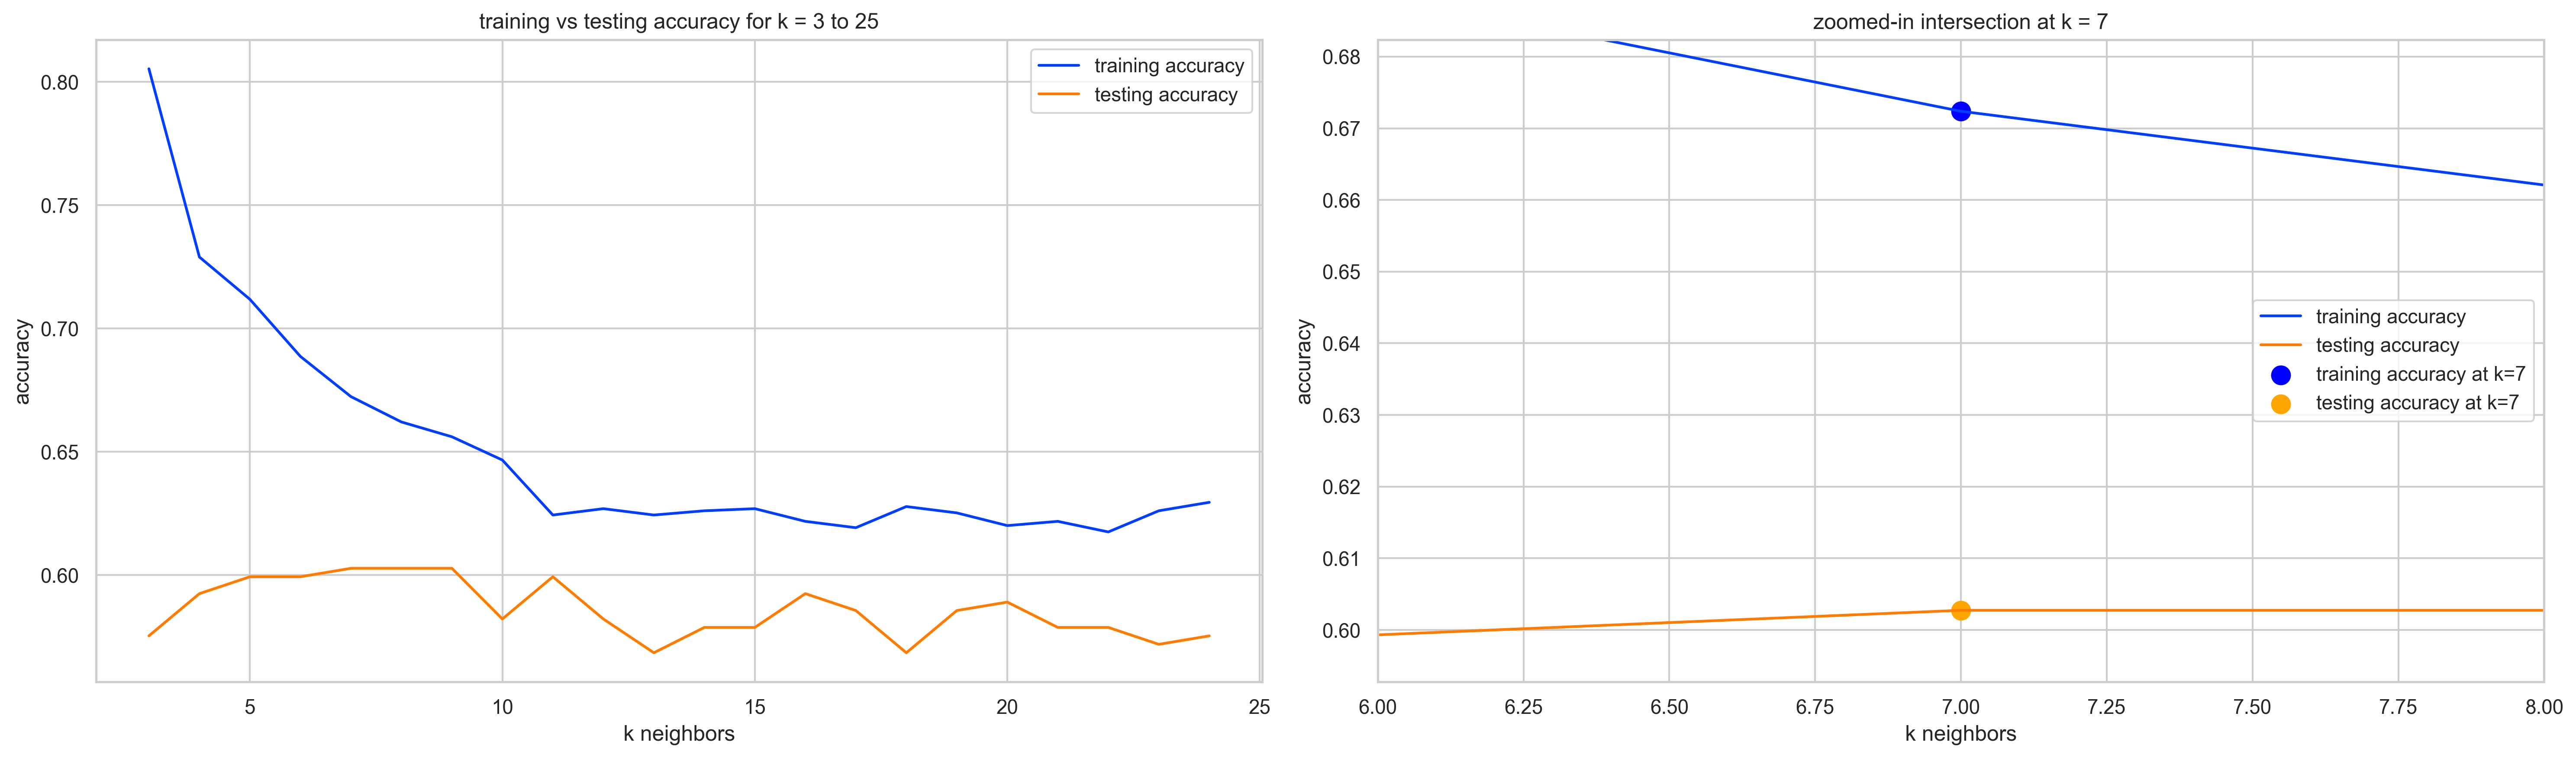

In [237]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# this function will find the best k value for the model
def find_best_k(X_train, y_train, X_test, y_test, k_range):
    training_accuracy = []
    testing_accuracy = []
    overfitting_scores = [] 
    best_k = 0
    best_score = 0
    
    k_values = np.arange(k_range[0], k_range[1], k_range[2])

    # iterating over the different k values
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        
        
        # training the model on the training data
        knn.fit(X_train, y_train)
        
        # evaluating the model on training data
        train_accuracy = knn.score(X_train, y_train)
        training_accuracy.append(train_accuracy)
        
        # evaluating the model on testing data
        test_accuracy = knn.score(X_test, y_test)
        testing_accuracy.append(test_accuracy)
        
        # calculating overfitting score (train - test accuracy)
        overfitting_score = train_accuracy - test_accuracy
        overfitting_scores.append(overfitting_score)
        
        # check if this is the best score so far
        if test_accuracy > best_score:
            best_k = k
            best_score = test_accuracy
    
    # analyze overfitting and underfitting
    analyze_overfitting_underfitting(k_values, overfitting_scores)
    
    return best_k, best_score, training_accuracy, testing_accuracy, k_values, overfitting_scores

# example usage of the function
best_k, best_score, training_accuracy, testing_accuracy, k_values, overfitting_scores = find_best_k(X_train, y_train, X_test, y_test, k_range=(3, 25, 1))

# get accuracy values and overfitting score for the chosen k
index_best_k = np.where(k_values == best_k)[0][0]
train_accuracy_at_best_k = training_accuracy[index_best_k]
test_accuracy_at_best_k = testing_accuracy[index_best_k]
overfitting_score_best_k = overfitting_scores[index_best_k]

# print results for the chosen k
print(f"\nbest k for range 3-25: {best_k}")
print(f"training accuracy at k={best_k}: {train_accuracy_at_best_k:.4f}")
print(f"testing accuracy at k={best_k}: {test_accuracy_at_best_k:.4f}")
print(f"overfitting score at k={best_k}: {overfitting_score_best_k:.4f}")

# plotting both the full range and zoomed-in plot side by side
plt.figure(figsize=(20, 6), dpi=300)

# full range plot
plt.subplot(1, 2, 1)
sns.lineplot(x=k_values, y=training_accuracy, label="training accuracy")
sns.lineplot(x=k_values, y=testing_accuracy, label="testing accuracy")
plt.title("training vs testing accuracy for k = 3 to 25")
plt.xlabel("k neighbors")
plt.ylabel("accuracy")
plt.legend()

# zoomed-in plot around best k
plt.subplot(1, 2, 2)
sns.lineplot(x=k_values, y=training_accuracy, label="training accuracy")
sns.lineplot(x=k_values, y=testing_accuracy, label="testing accuracy")
plt.xlim(best_k - 1, best_k + 1)  # zoom around best k
plt.ylim(min(train_accuracy_at_best_k, test_accuracy_at_best_k) - 0.01, 
         max(train_accuracy_at_best_k, test_accuracy_at_best_k) + 0.01)
plt.scatter([best_k], [train_accuracy_at_best_k], color="blue", s=100, label="training accuracy at k={}".format(best_k))
plt.scatter([best_k], [test_accuracy_at_best_k], color="orange", s=100, label="testing accuracy at k={}".format(best_k))
plt.title(f"zoomed-in intersection at k = {best_k}")
plt.xlabel("k neighbors")
plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Modeling

In [238]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=8)

# fitting  the model to the training data
knn.fit(X_train, y_train)

# predicting  on the test set
y_pred = knn.predict(X_test)

# calculating and print the accuracy and classification report
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# printing the classification report and create a DataFrame for it
report = classification_report(y_test, y_pred, output_dict=True, zero_division=1)
report_df = pd.DataFrame(report).transpose()

# displaying the DataFrame as a styled table with a background gradient
print("Classification Report:")
report_df_styled = report_df.style.background_gradient(axis=0)
display(report_df_styled)


Test Accuracy: 0.6027
Classification Report:


,precision,recall,f1-score,support
3,1.000000,0.000000,0.000000,2.000000
4,0.000000,0.000000,0.000000,5.000000
5,0.617188,0.681034,0.647541,116.000000
6,0.619403,0.614815,0.617100,135.000000
7,0.500000,0.466667,0.482759,30.000000
8,1.000000,0.000000,0.000000,4.000000
accuracy,0.602740,0.602740,0.602740,0.602740
macro avg,0.622765,0.293753,0.291233,292.000000
weighted avg,0.603470,0.602740,0.592144,292.000000


# HyperParameter Tuning

##### For each combination of parameters, GridSearchCV performs 5-fold cross-validation. 
##### This means the training data is divided into 5 folds, where the model is trained on 4 folds and validated on the remaining fold, repeating this process across all 5 folds. 
##### The average accuracy across these folds is computed for each parameter combination, and the combination with the highest average accuracy is chosen as the best set of parameters.

In [243]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# defining the parameter grid to search through, including different values for n_neighbors, weights, and algorithm used in the KNN model
param_grid = {
    'n_neighbors': [6, 8, 10, 12, 14, 16, 18, 20, 22, 24],  # try different values for k
    'weights': ['uniform', 'distance'],  # uniform and distance weights methods
    'metric': ['manhattan', 'euclidean'],  # different distance metrics
    'algorithm': ['ball_tree', 'kd_tree', 'brute']  # different algorithms
}

knn = KNeighborsClassifier()
# performing a GridSearchCV to find the best hyperparameters from the parameter grid with the highest accuracy
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Best parameters: {'algorithm': 'ball_tree', 'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'distance'}
Best cross-validation score: 0.6707


In [240]:
grid_search.best_estimator_

KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=20,
                     weights='distance')

In [241]:
grid_search.best_score_

np.float64(0.6706650526393017)

# making a model with the best parameters and checking the accuracy


In [242]:
from sklearn.metrics import accuracy_score
# use the best estimator from grid search
best_model = grid_search.best_estimator_

test_accuracy = best_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6815


##### the end of the notebook